# Выбор фондового рынка для дальнейшего исследования

Если основываться на различные источники информации без детального анализа, выбор фондового рынка Германии обусловлен его характеристиками как развитого и диверсифицированного рынка, где исторически характерны более низкие значения попарных корреляций доходностей акций по сравнению с другими рынками.

**DAX** (Deutscher Aktienindex) - основной индекс, включает 40 крупнейших компаний (таких как Volkswagen, Siemens, SAP, Allianz). Это аналог американского Dow Jones.   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
plt.style.use('ggplot')

Выбираем акции по двум критериям:   
*   Минимальное количество пропусков
*   Это крупнейшие компании, представляющие все ключевые сектора экономики Германии. Их движение действительно двигает рынок и отражает общие настроения инвесторов



Промышленность и производство:   
*   Siemens AG (SIE) — Промышленный конгломерат, электроника, энергетика.
*   Volkswagen AG (VOW) — Автопроизводитель.
*   Daimler AG (MBG) — Автопроизводитель (Mercedes-Benz).
*   BMW AG (BMW) — Автопроизводитель.
*   ThyssenKrupp AG (TKA) — Сталелитейная и промышленная компания.
*   Deutsche Lufthansa AG (LHA) — Авиаперевозчик.
*   Deutsche Post AG (DHL) — Почтовая и логистическая компания (владелец DHL).
   
   
Химическая и фармацевтическая промышленность:
*   BASF SE (BAS) — Крупнейший в мире химический концерн.
*   Bayer AG (BAYN) — Химико-фармацевтический концерн.
*   Merck KGaA (MRK) — Фармацевтическая и химическая компания.
*   Fresenius SE & Co. KGaA (FRE) — Здравоохранение, международная компания в области медицинских услуг.
*   Fresenius Medical Care AG & Co. KGaA (FME) — Специализируется на диализе (часто выделяется как отдельная компания, но тесно связана с Fresenius).
   
   
Финансовый сектор:
*   Allianz SE (ALV) — Страховая компания, один из крупнейших финансовых конгломератов.
*   Münchener Rückversicherungs-Gesellschaft AG (MUV2) — Перестраховочная компания (Munich Re).
*   Deutsche Bank AG (DBK) — Крупнейший банк Германии.
*   Commerzbank AG (CBK) — Второй по величине банк Германии.
   
   
Ритейл и потребительские товары:
*   Adidas AG (ADS) — Производитель спортивной одежды и обуви.
*   Beiersdorf AG (BEI) — Производитель товаров для ухода (Nivea, etc.).
*   Henkel(HEN3) — крупный немецкий производитель товаров для дома и косметики (Persil, Schwarzkopf).
   
   
Технологии и телекоммуникации:
*   SAP SE (SAP) — Разработчик программного обеспечения, крупнейшая техкомпания Европы.
*   Deutsche Telekom AG (DTE) — Телекоммуникационный гигант.
*   Infineon Technologies AG (IFX) — Производитель полупроводников.
   
   
Энергетика и коммунальные услуги:
*   E.ON SE (EOAN) — Энергетическая компания.
*   RWE AG (RWE) — Энергетическая компания.
   
   
Прочее:
*   Continental AG (CON) — Производитель шин и автомобильных компонентов.

In [3]:
tickers = [
    'SIE', 'VOW', 'MBG', 'BMW', 'TKA', 'DHL',
    'LHA', 'BAS', 'BAYN', 'MRK', 'FRE', 'FME',
    'ALV', 'MUV2', 'DBK', 'CBK', 'ADS', 'BEI',
    'HEN3', 'SAP', 'DTE', 'IFX', 'EOAN', 'RWE', 'CON'
]
tickers = [ticker + '.DE' for ticker in tickers]
initial_df = yf.download(tickers, start='2005-01-01', end='2013-01-01', auto_adjust=True)['Close']
initial_df.head(5)

[*********************100%***********************]  25 of 25 completed


Ticker,ADS.DE,ALV.DE,BAS.DE,BAYN.DE,BEI.DE,BMW.DE,CBK.DE,CON.DE,DBK.DE,DHL.DE,...,IFX.DE,LHA.DE,MBG.DE,MRK.DE,MUV2.DE,RWE.DE,SAP.DE,SIE.DE,TKA.DE,VOW.DE
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,23.480192,39.085339,10.290375,14.040274,21.258274,15.662538,101.639015,26.694902,30.632357,15.669333,...,5.931499,4.268898,9.514894,18.830332,37.405735,17.610071,22.780338,27.144625,10.954883,17.265162
2005-01-04,23.359802,39.249886,10.253734,13.838901,21.634529,15.973467,101.705002,27.086653,30.497269,15.478796,...,5.829232,4.301267,9.613562,18.531612,37.802059,17.627209,22.333670,26.993704,11.035534,17.686020
2005-01-05,23.068531,38.700069,10.159240,13.486493,21.632057,16.029158,102.695000,26.778852,30.101320,15.424357,...,5.770795,4.256758,9.578895,18.114876,37.189190,18.137083,22.195164,26.601299,10.867513,17.675877
2005-01-06,23.175329,39.089355,10.155381,13.492086,21.592453,16.108051,106.060966,27.058668,31.060913,15.469723,...,5.785404,4.305314,9.629564,18.162819,37.953243,18.411306,22.627987,26.851402,10.961603,18.203213
2005-01-07,23.039402,39.121468,10.199739,13.452932,21.587500,16.057003,107.314957,27.002703,31.242580,15.560455,...,5.807318,4.309361,9.581562,18.074312,38.243336,18.616970,23.085049,26.989393,10.995209,18.238707


In [4]:
df = pd.DataFrame([initial_df.iloc[row] / initial_df.iloc[row-1] for row in range(1, initial_df.shape[0])], index=initial_df.index[1:]) # расчет доходностей
df = np.log(df) # логарифмические доходности
df.dropna(inplace=True, axis=0)
df.head()

Ticker,ADS.DE,ALV.DE,BAS.DE,BAYN.DE,BEI.DE,BMW.DE,CBK.DE,CON.DE,DBK.DE,DHL.DE,...,IFX.DE,LHA.DE,MBG.DE,MRK.DE,MUV2.DE,RWE.DE,SAP.DE,SIE.DE,TKA.DE,VOW.DE
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-04,-0.005140,0.004201,-0.003567,-0.014446,0.017544,0.019657,0.000649,0.014568,-0.004420,-0.012234,...,-0.017392,0.007554,0.010316,-0.015991,0.010540,0.000973,-0.019802,-0.005575,0.007335,0.024084
2005-01-05,-0.012547,-0.014107,-0.009258,-0.025795,-0.000114,0.003480,0.009687,-0.011429,-0.013068,-0.003523,...,-0.010075,-0.010402,-0.003613,-0.022745,-0.016345,0.028515,-0.006221,-0.014644,-0.015343,-0.000574
2005-01-06,0.004619,0.010009,-0.000380,0.000415,-0.001832,0.004910,0.032251,0.010395,0.031381,0.002937,...,0.002528,0.011342,0.005276,0.002643,0.020337,0.015006,0.019313,0.009358,0.008621,0.029397
2005-01-07,-0.005882,0.000821,0.004358,-0.002906,-0.000229,-0.003174,0.011754,-0.002070,0.005832,0.005848,...,0.003781,0.000940,-0.004997,-0.004885,0.007614,0.011109,0.019998,0.005126,0.003061,0.001948
2005-01-10,0.000253,-0.002157,-0.007020,0.003321,-0.009331,-0.002894,0.001843,0.003311,-0.000447,-0.005848,...,0.001257,0.000939,-0.002787,0.001631,0.004264,-0.003458,-0.002553,-0.000959,0.012754,0.005821


In [5]:
pd.set_option('display.width', 400)
pd.set_option('display.max_columns', 26)
corr_list = []

for year in range(2006, 2013):
  curr_year_df = df[df.index.year == year]
  year_corr = curr_year_df.corr() # выводим корреляционные матрицы
  corr_list.append(year_corr.where(np.triu(np.ones(year_corr.shape), k=1).astype(bool))) # сохраняем верхний треугольник для гистограммы
  print(f'{'-'*125}YEAR {year}{'-'*125}')
  print(f'{year_corr}\n')

-----------------------------------------------------------------------------------------------------------------------------YEAR 2006-----------------------------------------------------------------------------------------------------------------------------
Ticker     ADS.DE    ALV.DE    BAS.DE   BAYN.DE    BEI.DE    BMW.DE    CBK.DE    CON.DE    DBK.DE    DHL.DE    DTE.DE   EOAN.DE    FME.DE    FRE.DE   HEN3.DE    IFX.DE    LHA.DE    MBG.DE    MRK.DE   MUV2.DE    RWE.DE    SAP.DE    SIE.DE    TKA.DE    VOW.DE
Ticker                                                                                                                                                                                                                                                           
ADS.DE   1.000000  0.476904  0.385248  0.367350  0.400614  0.387655  0.345590  0.417096  0.474289  0.260435  0.284759  0.363446  0.346700  0.295623  0.267514  0.349264  0.324524  0.402794  0.305601  0.473712  0.272561  0.356

Коэффициенты корреляций оказались не такими низкими, как ожидалось. Рассмотрим их гистограмму:

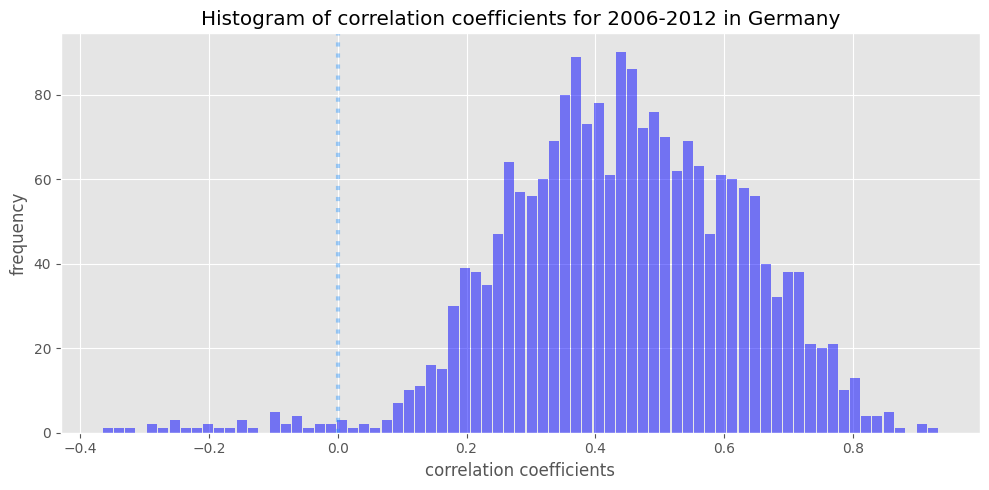

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.array(corr_list).flatten(), bins=75, color='#0000FF', rwidth=0.9, alpha=0.5)
ax.axvline(x=0, color='#1E90FF', linestyle=':', linewidth=3, alpha=0.4)
plt.xlabel('correlation coefficients', fontsize=12)
plt.ylabel('frequency', fontsize=12)
plt.title('Histogram of correlation coefficients for 2006-2012 in Germany')
plt.tight_layout()
plt.show()

Стоит пересмотреть свой выбор рынка и оценить ситуацию на других рынках - возможно, они имеют более низкое значение пика.

In [7]:
def get_avg_correlations(tickers, start, end): # расчет средних корреляций
    prices = yf.download(tickers, start=start, end=end, auto_adjust=True)['Close']
    log_returns = np.log(prices / prices.shift(1)).dropna()

    avg_corrs = []
    years = []

    for year in range(2006, 2020):
        year_data = log_returns[log_returns.index.year == year]
        corr_mat = year_data.corr()
        upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
        avg_corr = upper_tri.stack().mean()
        avg_corrs.append(avg_corr)
        years.append(year)

    return years, avg_corrs

График для сравнения рынков разных стран:

[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  25 of 25 completed
[*********************100%***********************]  24 of 24 completed


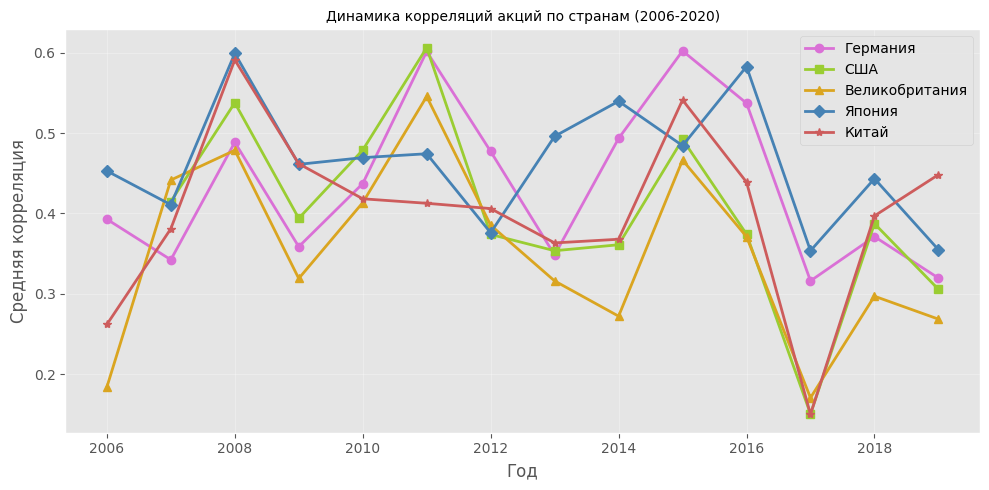

In [8]:
de_tickers = ['SIE.DE', 'VOW.DE', 'MBG.DE', 'BMW.DE', 'TKA.DE', 'DHL.DE',
              'LHA.DE', 'BAS.DE', 'BAYN.DE', 'MRK.DE', 'FRE.DE', 'FME.DE',
              'ALV.DE', 'MUV2.DE', 'DBK.DE', 'CBK.DE', 'ADS.DE', 'BEI.DE',
              'HEN3.DE', 'SAP.DE', 'DTE.DE', 'IFX.DE', 'EOAN.DE', 'RWE.DE', 'CON.DE']

us_tickers = ['GE', 'F', 'NUE', 'UPS', 'DAL', 'DD', 'PFE', 'JNJ', 'DVA',
              'BRK-B', 'AIG', 'C', 'BAC', 'NKE', 'PG', 'CL', 'MSFT',
              'T', 'INTC', 'XOM', 'CVX', 'BWA', 'WMT', 'KO', 'MCD']

uk_tickers = ['BP', 'SHEL.L', 'HSBA.L', 'LLOY.L', 'BARC.L', 'ANTO.L', 'RIO.L',
              'AAL.L', 'ULVR.L', 'DGE.L', 'AZN.L', 'GSK.L', 'VOD.L', 'TSCO.L',
              'RR.L', 'PRU.L', 'AV.L', 'LSEG.L', 'EXPN.L', 'REL.L', 'ABF.L',
              'SBRY.L', 'STAN.L', 'LGEN.L', 'III.L']

jp_tickers = ['7203.T', '7267.T', '7201.T', '6954.T', '6758.T', '6702.T',
              '6501.T', '6971.T', '8306.T', '8316.T', '8411.T', '7751.T',
              '6752.T', '4502.T', '4503.T', '8058.T', '8031.T', '9501.T',
              '9983.T', '8267.T', '9432.T', '7011.T', '7731.T', '7733.T','6504.T']

cn_tickers = [
    '000002.SZ', '000063.SZ', '000858.SZ', '600000.SS', '600011.SS',
    '600016.SS', '600019.SS', '600028.SS', '600029.SS', '600030.SS',
    '600036.SS', '600048.SS', '600050.SS', '600104.SS', '600115.SS',
    '600188.SS', '600256.SS', '600406.SS', '600519.SS', '600690.SS',
    '600887.SS', '601111.SS', '601398.SS', '601988.SS'
]
years_data = {}
corrs_data = {}

countries = [
    ('Германия', de_tickers),
    ('США', us_tickers),
    ('Великобритания', uk_tickers),
    ('Япония', jp_tickers),
    ('Китай', cn_tickers)
]
colors = {
    'Германия': '#DA70D6',
    'США': '#9ACD32',
    'Великобритания': '#DAA520',
    'Япония': '#4682B4',
    'Китай': '#CD5C5C'
}
markers = {
    'Германия': 'o',
    'США': 's',
    'Великобритания': '^',
    'Япония': 'D',
    'Китай': '*'
}

for name, tickers in countries:
    years, corrs = get_avg_correlations(tickers, '2006-01-01', '2020-01-01')
    if years and corrs:
        years_data[name] = years
        corrs_data[name] = corrs

plt.figure(figsize=(10, 5))

for name in years_data:
    plt.plot(years_data[name], corrs_data[name],
             marker=markers[name], linestyle='-', linewidth=2, markersize=6,
             label=name, color=colors[name])

plt.xlabel('Год', fontsize=12)
plt.ylabel('Средняя корреляция', fontsize=12)
plt.title('Динамика корреляций акций по странам (2006-2020)', fontsize=10)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Но средняя корреляция для 25 случайно выбранных акций - не самый надежный показатель для выбора рынка. Чтобы выбор рынка был более обоснованным, рассмотрим среди 25 акций каждого рынка 10 акций с наиболее низкой корреляцией.
Также, 10 акций проще визуализировать в дальнейших результатах, нежели 25 штук.

In [9]:
def get_peak_correlation(tickers, start='2005-01-01', end='2013-01-01', bins=75): # вычисление пика распределения
    prices = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)['Close']

    # логарифмические доходности
    df = pd.DataFrame([prices.iloc[row] / prices.iloc[row-1] for row in range(1, prices.shape[0])],
                      index=prices.index[1:])
    df = np.log(df)
    df.dropna(inplace=True, axis=0)

    # все корреляции за все годы
    corr_list = []
    for year in range(2005, 2013):
        curr_year_df = df[df.index.year == year]
        if len(curr_year_df) > 0:
            year_corr = curr_year_df.corr()
            corr_list.append(year_corr.where(np.triu(np.ones(year_corr.shape), k=1).astype(bool)))

    all_corrs = np.array(corr_list).flatten()
    all_corrs_clean = all_corrs[~np.isnan(all_corrs)]

    # пик распределения
    hist, bin_edges = np.histogram(all_corrs_clean, bins=bins)
    peak_bin = np.argmax(hist)
    peak = bin_edges[peak_bin]

    return peak

In [10]:
def get_top_10_low_correlated(tickers, start='2005-01-01', end='2013-01-01'):
    prices = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)['Close']

    # логарифмические доходности
    df = pd.DataFrame([prices.iloc[row] / prices.iloc[row-1] for row in range(1, prices.shape[0])],
                      index=prices.index[1:])
    df = np.log(df)
    df.dropna(inplace=True, axis=0)

    # на основе данных за 2005 год для чистоты эксперимента
    df_2005 = df[df.index.year == 2005]
    corr_2005 = df_2005.corr()

    # средняя абсолютная корреляция для каждой акции
    avg_corrs = {}
    for asset in tickers:
        if asset in corr_2005.index:
            corr_series = corr_2005[asset].drop(asset)
            avg_corrs[asset] = corr_series.abs().mean()

    # берём топ-10
    sorted_assets = sorted(avg_corrs.items(), key=lambda x: x[1]) # сортируем
    top_10 = [asset for asset, _ in sorted_assets[:10]] # берём топ-10

    return top_10

In [11]:
markets_25 = {
    'ФРГ': de_tickers,
    'США': us_tickers,
    'Великобритания': uk_tickers,
    'Япония': jp_tickers,
    'Китай': cn_tickers
}

peaks_25 = {}

for name, tickers in markets_25.items():
  peak = get_peak_correlation(tickers)
  peaks_25[name] = peak

In [12]:
print("\n" + "-"*145)
print("Топ-10 низкокоррелированных акций по рынкам")
print("-"*145)

peaks_top10 = {}

for name, tickers in markets_25.items():
  top_10 = get_top_10_low_correlated(tickers)
  peak = get_peak_correlation(top_10)
  peaks_top10[name] = peak
  print(f"Для {name} топ-10 акций: {top_10}")


-------------------------------------------------------------------------------------------------------------------------------------------------
Топ-10 низкокоррелированных акций по рынкам
-------------------------------------------------------------------------------------------------------------------------------------------------
Для ФРГ топ-10 акций: ['FRE.DE', 'BEI.DE', 'MRK.DE', 'FME.DE', 'ADS.DE', 'HEN3.DE', 'DHL.DE', 'CON.DE', 'TKA.DE', 'BMW.DE']
Для США топ-10 акций: ['GE', 'F', 'NUE', 'UPS', 'DAL', 'DD', 'PFE', 'JNJ', 'DVA', 'BRK-B']
Для Великобритания топ-10 акций: ['BP', 'SHEL.L', 'HSBA.L', 'LLOY.L', 'BARC.L', 'ANTO.L', 'RIO.L', 'AAL.L', 'ULVR.L', 'DGE.L']
Для Япония топ-10 акций: ['4503.T', '8267.T', '6702.T', '9983.T', '7011.T', '9501.T', '8316.T', '8306.T', '8031.T', '7201.T']
Для Китай топ-10 акций: ['000002.SZ', '000063.SZ', '000858.SZ', '600000.SS', '600011.SS', '600016.SS', '600019.SS', '600028.SS', '600029.SS', '600030.SS']


In [13]:
print("\n" + "="*65)
print(" "*10, "Сводная таблица для пиков распределений")
print("="*65)
print(f"{'Рынок':<20} {'25 акций':<15} {'Топ-10 низкокоррелированных':<30}")
print("-"*65)

for name in markets_25.keys():
    peak_25 = peaks_25.get(name, float('nan'))
    peak_top10 = peaks_top10.get(name, float('nan'))
    print(f"{name:<20} {peak_25:<15.6f} {peak_top10:<30.6f}")


           Сводная таблица для пиков распределений
Рынок                25 акций        Топ-10 низкокоррелированных   
-----------------------------------------------------------------
ФРГ                  0.431120        0.177791                      
США                  0.573644        0.420552                      
Великобритания       0.389297        0.488794                      
Япония               0.452969        0.354343                      
Китай                0.371545        0.396122                      


Пики для рынков Японии и Германии вычислялись с учетом 2005 года - периода более низких корреляций для всех рынков.   
К сожалению, YFinance имеет данные акций Китая, Великобритании и США только начиная с 2006-2007 года, когда коэффициенты корреляции сильно больше, чем были в 2005 году.   
   
Чем ближе пик к 0 - тем лучше для статистик вида   
   
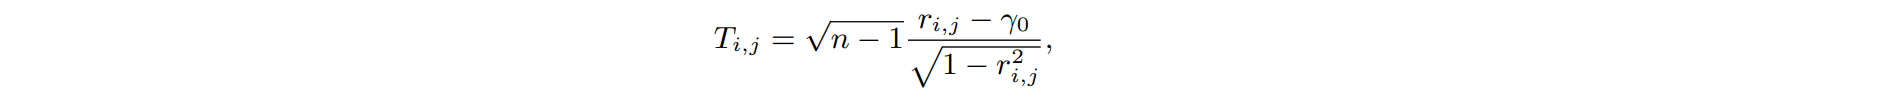  
    
где gamma0 - пороговый коэффициент, близкий к пику, r_ij - выборочный коэффициент корреляции Пирсона. При gamma0 = 0 будет получено асимптотически  хорошее распределение Стьюдента (это очень близко к стандартному распределению). Также, малое значение gamma0 отображает реальную картину - инвесторы строят диверсифицированные портфели, состоящие из пар акций с наиболее низкими корреляциями.


**Было принято решение выбрать 10 акций ФРГ**.